# 02 - Prétraitement et filtrage

## Objectif

Préparer les images avant l'analyse : redimensionnement, réduction du bruit et amélioration du contraste.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.append(str(PROJECT_ROOT))

import matplotlib.pyplot as plt

from src.filtering import apply_clahe, bilateral_denoise, equalize_histogram, gaussian_blur, median_blur
from src.preprocessing import read_grayscale_image, resize_image
from src.utils import build_image_index, display_images

## 1. Choix d'une image d'exemple

On prend une image Defective si elle existe, sinon la première image disponible.

C:\Users\espacegamers\Desktop\Master IAII\Cours\drive-download-20251005T182208Z-1-001\S2\Traitement d_images et vision par ordinateur_\Projet\industrial-defect-detection2\data\raw\casting_data\train\def_front\cast_def_0_0.jpeg


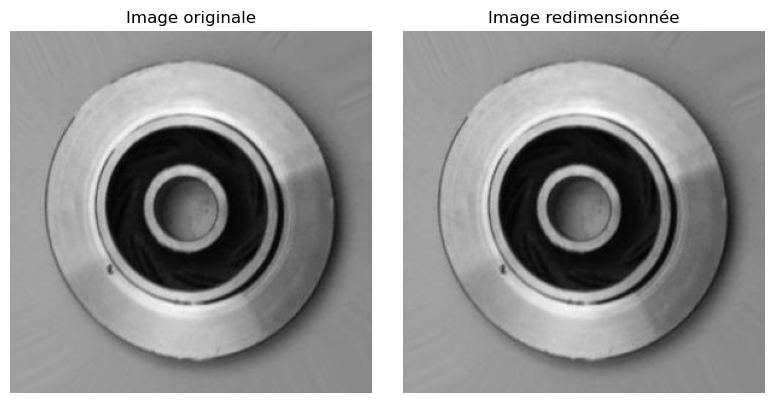

In [2]:
index_df = build_image_index()

if index_df.empty:
    raise FileNotFoundError("Aucune image trouvée dans data/raw/casting_data/.")

candidate = index_df[(index_df["split"] == "train") & (index_df["label_name"] == "Defective")]
sample_row = candidate.iloc[0] if not candidate.empty else index_df.iloc[0]

image = read_grayscale_image(sample_row["path"])
resized = resize_image(image, size=(300, 300))

print(sample_row["path"])
display_images([image, resized], titles=["Image originale", "Image redimensionnée"], cols=2, figsize=(8, 4))

## 2. Application de filtres

Les filtres réduisent le bruit et facilitent les étapes suivantes comme le seuillage et la détection de contours.

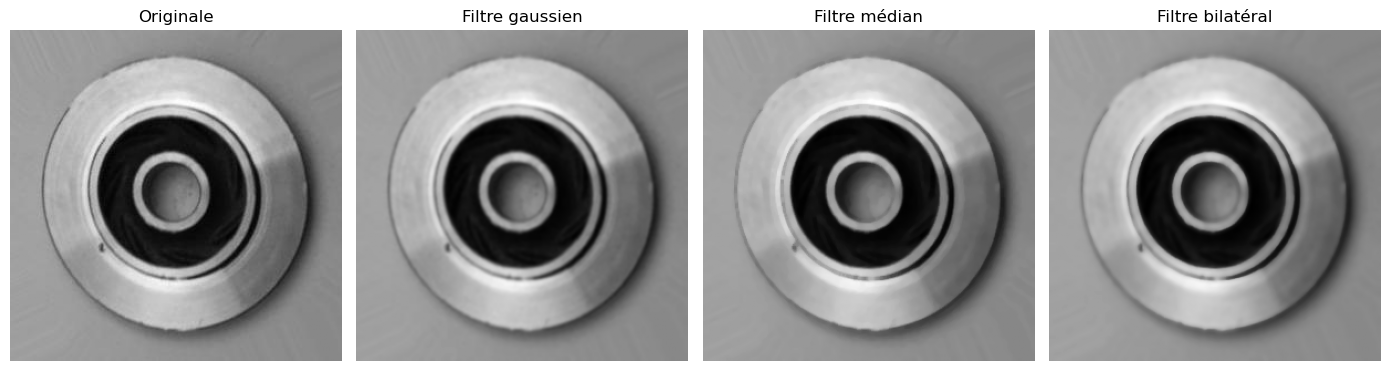

In [3]:
gaussian = gaussian_blur(resized)
median = median_blur(resized)
bilateral = bilateral_denoise(resized)

display_images(
    [resized, gaussian, median, bilateral],
    titles=["Originale", "Filtre gaussien", "Filtre médian", "Filtre bilatéral"],
    cols=4,
    figsize=(14, 4),
)

## 3. Amélioration du contraste

On compare l'égalisation globale et CLAHE. CLAHE est souvent plus stable car il améliore le contraste localement.

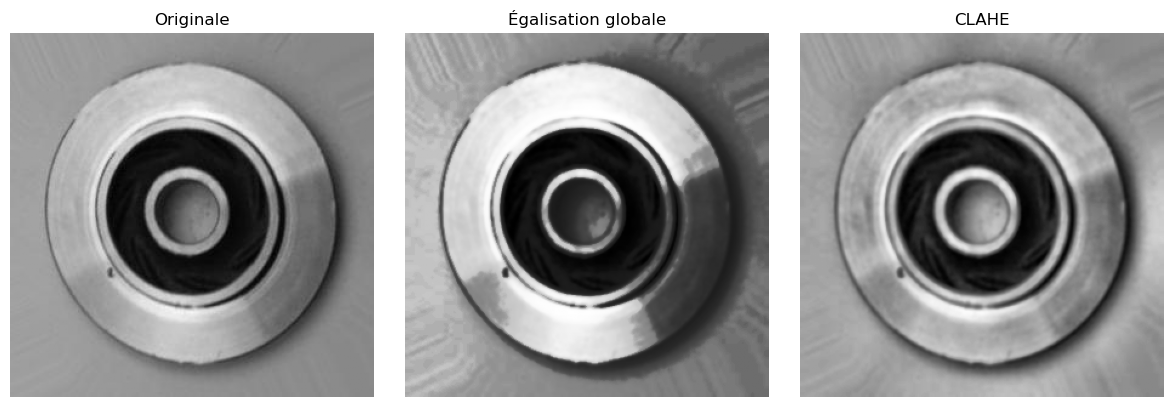

In [4]:
equalized = equalize_histogram(gaussian)
clahe = apply_clahe(gaussian)

display_images(
    [resized, equalized, clahe],
    titles=["Originale", "Égalisation globale", "CLAHE"],
    cols=3,
    figsize=(12, 4),
)

## 4. Histogrammes

Les histogrammes montrent comment les niveaux de gris sont répartis avant et après amélioration du contraste.

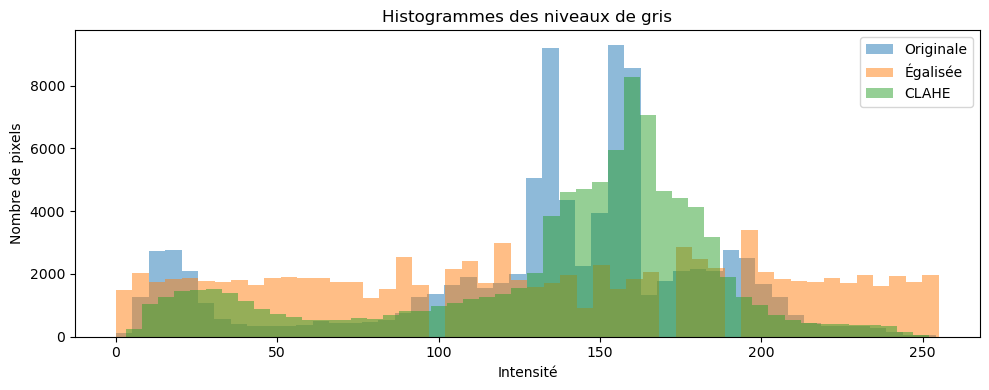

In [5]:
plt.figure(figsize=(10, 4))
for img, label in [(resized, "Originale"), (equalized, "Égalisée"), (clahe, "CLAHE")]:
    plt.hist(img.ravel(), bins=50, alpha=0.5, label=label)
plt.title("Histogrammes des niveaux de gris")
plt.xlabel("Intensité")
plt.ylabel("Nombre de pixels")
plt.legend()
plt.tight_layout()
plt.show()

## Conclusion

Le prétraitement retenu pour la suite est volontairement simple : resize, filtre gaussien léger et CLAHE.